# Projeto Avaliativo - Módulo 1 - Semana 14
 
# Predicting Life Expectancy Using the WHO Health Inequality Data Repository (HIDR)

## Beyond the Numbers: Predicting Life Expectancy from Global Health Inequalities

**Author:** Ananda Christina Staats Pires

**Institution:** Fundamentos de Dados, Programação e Análise Preditiva com Python, SENAI - Programa SCTEC

**Project Type:** End-to-End Machine Learning Regression Pipeline

**Date:** July 2026

## 1. Introduction

Life expectancy is a key indicator of population health and socioeconomic development. It reflects the combined influence of healthcare access, disease burden, environmental exposures, behavioural risk factors, and social determinants of health.

This project develops a supervised machine learning regression pipeline to predict life expectancy using publicly available indicators from the World Health Organization (WHO) Health Inequality Data Repository (HIDR).

Unlike conventional machine learning datasets containing a single pre-processed table, this project integrates multiple WHO thematic datasets into a unified country-year analytical dataset. The workflow includes data acquisition, indicator screening, dataset harmonization, exploratory data analysis, feature preparation, regression modelling, and model evaluation.

The final objective is to investigate how multidimensional health inequality indicators contribute to variations in life expectancy across countries and over time.

## 2. Problem Definition

Life expectancy summarizes the overall health status of populations and is widely used for monitoring health inequalities and supporting evidence-based policy decisions.

The objective of this project is to develop a regression model capable of predicting life expectancy using indicators representing socioeconomic conditions, environmental exposures, behavioural risk factors, and healthcare system characteristics.

By integrating multiple domains of population health, the model aims to provide an interpretable framework for understanding the contribution of different determinants to population health outcomes.

## 3. Project Objectives

### General Objective

Develop an end-to-end machine learning regression pipeline to predict life expectancy using global health indicators from the WHO Health Inequality Data Repository.

### Specific Objectives

- Retrieve health inequality indicators through the WHO HIDR API.
- Screen and select epidemiologically relevant predictors.
- Harmonize heterogeneous datasets into a country-year analytical structure.
- Perform exploratory data analysis and assess data quality.
- Prepare features for regression modelling.
- Train and evaluate predictive models.
- Document the complete workflow following reproducible data science practices.

## 4. Data Source


The data used in this project were obtained from the **World Health Organization (WHO) Health Inequality Data Repository (HIDR)**.

The HIDR is a comprehensive repository of harmonized international health indicators covering multiple dimensions of population health, including health outcomes, healthcare systems, environmental conditions, behavioural risk factors, and socioeconomic determinants.

All datasets were accessed programmatically through the official WHO API, ensuring reproducibility and facilitating future updates as new data become available.

### Citation

> World Health Organization. *Health Inequality Data Repository API*. Geneva: WHO, 2025. Available at: https://www.who.int/data/inequality-monitor/data. Accessed on 09 July 2026.

## 5. Project Structure

The project follows a modular structure in which reusable functions are implemented inside the `src/` directory.

Main modules include:

- `config.py` – project configuration and file paths
- `dataset.py` – dataset download and file management
- `feature_selection.py` – indicator screening and variable selection
- `harmonization.py` – data harmonization and analytical dataset construction
- `visualization.py` – reusable plotting functions
- `preprocessing.py` – preprocessing and feature engineering
- `modeling.py` – model training
- `evaluation.py` – model evaluation

In [1]:
# Configure project paths

import os
import sys
from pathlib import Path

root = Path.cwd()

while not (root / "src").is_dir() and root != root.parent:
    root = root.parent

os.chdir(root)

if str(root) not in sys.path:
    sys.path.insert(0, str(root))

print(f"Project root: {root}")

Project root: /Users/anandastaats/who-life-expectancy_prediction


## 5. Import Libraries

The project uses reusable modules implemented in the `src` package together with standard scientific Python libraries.

Separating reusable functions from the notebook improves readability and facilitates future maintenance.

In [2]:
# Import libraries

import numpy as np
import pandas as pd

from IPython.display import display

from src.dataset import (
    load_hidr_dataset,
    dataset_summary,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

## 6. Download WHO Datasets

The analytical dataset is constructed by integrating multiple thematic datasets from the WHO Health Inequality Data Repository.

Each dataset is downloaded automatically through the reusable data loader. Downloaded files are stored locally and cached to avoid repeated downloads in future executions.

In [3]:
# Download selected WHO HIDR datasets

selected_datasets = {

    "mortality": "rep_gho_mortality",
    "healthcare": "rep_gho_hc",
    "ncd": "rep_gho_ncd",
    "tobacco": "rep_gho_tobacco",
    "alcohol": "rep_gho_alcohol",
    "environment": "rep_gho_env",
    "wash": "rep_wash",
    "poverty": "rep_mpi",
    "world_bank": "rep_wb",
    "development": "rep_gdl2",
}

datasets = {
    name: load_hidr_dataset(dataset_id)
    for name, dataset_id in selected_datasets.items()
}

Loading cached dataset: rep_gho_mortality
Shape: (166980, 24)
Loading cached dataset: rep_gho_hc
Shape: (99976, 24)
Loading cached dataset: rep_gho_ncd
Shape: (625089, 24)
Loading cached dataset: rep_gho_tobacco
Shape: (21882, 24)
Loading cached dataset: rep_gho_alcohol
Shape: (68901, 24)
Loading cached dataset: rep_gho_env
Shape: (138282, 24)
Loading cached dataset: rep_wash
Shape: (136907, 24)
Loading cached dataset: rep_mpi
Shape: (8994, 24)
Loading cached dataset: rep_wb
Shape: (350088, 24)
Loading cached dataset: rep_gdl2
Shape: (608520, 24)


In [4]:
# Summarize downloaded datasets

dataset_summary(datasets)

,Dataset,Rows,Columns
0,ncd,625089,24
1,development,608520,24
2,world_bank,350088,24
3,mortality,166980,24
4,environment,138282,24
5,wash,136907,24
6,healthcare,99976,24
7,alcohol,68901,24
8,tobacco,21882,24
9,poverty,8994,24


## 7. Indicator Screening

The WHO HIDR datasets contain hundreds of indicators covering multiple dimensions of population health.

Before selecting predictors, an initial screening was performed to evaluate indicator availability across countries and years.

The screening considered:

- geographical coverage;
- temporal availability;
- number of observations;
- completeness.

This step supports transparent feature selection before constructing the analytical dataset.

In [5]:
# Calculate indicator coverage

from src.feature_selection import (
    calculate_indicator_coverage,
    display_screening_results,
)


coverage = calculate_indicator_coverage(
    datasets
)

coverage.head()

,dataset,indicator_name,countries,years,observations,missing
0,mortality,Adult mortality rate (probability of dying bet...,185,22,8140,0.00
1,mortality,"Air pollution attributable DALYs, ambient (per...",183,1,366,0.00
2,mortality,"Air pollution attributable DALYs, ambient (per...",183,1,366,0.00
3,mortality,"Air pollution attributable DALYs, ambient (per...",183,1,366,0.00
4,mortality,"Air pollution attributable DALYs, ambient (per...",183,1,366,0.00


In [6]:
# Display best covered indicators from each dataset

display_screening_results(
    coverage,
    n=10
)

Dataset: alcohol


,dataset,indicator_name,countries,years,observations,missing
234,alcohol,"Alcohol, abstainers in past 12 months (%)",194,21,7859,0.11
245,alcohol,"Alcohol, heavy episodic drinking in past 30 da...",194,21,7858,0.13
246,alcohol,"Alcohol, heavy episodic drinking in past 30 da...",194,21,7858,0.13
235,alcohol,"Alcohol, abstainers lifetime (%)",194,21,7854,0.18
237,alcohol,"Alcohol, consumers in past 12 months (age-stan...",194,21,7854,0.18
239,alcohol,"Alcohol, former drinkers (%)",194,21,7854,0.18
240,alcohol,"Alcohol, harmful use, 12 month prevalence (15+...",194,1,0,100.00
249,alcohol,"Alcohol, per capita consumption (15+ years, am...",191,21,7670,2.44
236,alcohol,"Alcohol, average daily intake among drinkers (...",189,21,7858,0.00
238,alcohol,"Alcohol, current drinkers (youth 15-19 years) (%)",189,2,756,0.00


Dataset: development


,dataset,indicator_name,countries,years,observations,missing
412,development,Expected years of schooling (children aged 6),164,33,55123,0.00
432,development,Life expectancy (years),164,33,55057,0.00
435,development,Mean years of schooling (population aged 25+),164,33,55023,0.00
413,development,Expected years of schooling (children aged 6) ...,164,23,37800,0.00
414,development,Expected years of schooling (children aged 6) ...,164,23,37799,0.00
436,development,Mean years of schooling (population aged 25+) ...,164,23,37749,0.00
437,development,Mean years of schooling (population aged 25+) ...,164,23,37738,0.00
433,development,Life expectancy (years) - Female,163,23,37310,0.00
434,development,Life expectancy (years) - Male,163,23,37310,0.00
422,development,Households with a phone (%),126,32,7587,0.03


Dataset: environment


...

,dataset,indicator_name,countries,years,observations,missing
231,tobacco,Tobacco: current cigarette smoking among adole...,191,19,356,6.81
220,tobacco,"Tobacco, current tobacco use among adolescents...",191,19,282,26.18
216,tobacco,"Tobacco, current tobacco smoking among adolesc...",191,19,208,45.55
224,tobacco,"Tobacco, daily cigarette smoking among adolesc...",191,19,54,85.86
228,tobacco,"Tobacco, daily tobacco smoking among adolescen...",191,19,14,96.34
217,tobacco,"Tobacco, current tobacco smoking among adults ...",190,17,276,27.37
221,tobacco,"Tobacco, current tobacco use among adults (sur...",190,17,210,44.74
232,tobacco,Tobacco: current cigarette smoking among adult...,190,17,210,44.74
229,tobacco,"Tobacco, daily tobacco smoking among adults (s...",190,17,195,48.68
225,tobacco,"Tobacco, daily cigarette smoking among adults ...",190,17,106,72.11


Dataset: wash


,dataset,indicator_name,countries,years,observations,missing
315,wash,Population using basic drinking water services...,173,25,8516,0.00
318,wash,Population using limited drinking water servic...,173,25,8516,0.00
324,wash,Population using unimproved drinking water ser...,173,25,8516,0.00
323,wash,Population using surface water (%),173,25,8278,0.00
317,wash,Population using basic sanitation services (%),171,25,8370,0.00
320,wash,Population using limited sanitation services (%),171,25,8370,0.00
325,wash,Population using unimproved sanitation service...,171,25,8370,0.00
314,wash,Population practising open defecation (%),171,25,8292,0.00
316,wash,Population using basic hygiene services (%),111,25,3346,0.00
326,wash,Population with no hygiene services (%),110,25,3460,0.00


Dataset: world_bank


,dataset,indicator_name,countries,years,observations,missing
379,world_bank,Land area where elevation is below 5 meters (%...,195,3,1170,0.00
387,world_bank,Population living in areas where elevation is ...,195,3,1170,0.00
384,world_bank,Over-age students in primary education (% of e...,193,50,8295,0.18
362,world_bank,"Educational attainment, at least completed low...",191,53,4233,0.12
364,world_bank,"Educational attainment, at least completed pri...",191,50,4010,0.00
388,world_bank,Primary completion rate (% of relevant age group),190,54,9595,0.03
366,world_bank,"Educational attainment, at least completed upp...",189,52,4156,0.00
354,world_bank,Children out of school (% of primary school age),188,54,7534,0.03
390,world_bank,Repeaters of primary education (% of total enr...,188,50,8542,0.00
382,world_bank,Lower secondary completion rate (% of relevant...,186,54,7726,0.05


### Interpretation

The screening step demonstrates substantial variability in indicator availability across WHO HIDR datasets.

Some indicators present broad geographical and temporal coverage, whereas others are limited to specific countries or years.

Coverage assessment is essential because predictors with insufficient availability may substantially reduce the number of observations available for modelling.

The final feature selection therefore considers not only statistical availability, but also epidemiological relevance, interpretability, and redundancy between indicators.

## 8. Feature Selection Strategy

The final predictors were selected based on four criteria:

- epidemiological relevance;
- global availability;
- low redundancy;
- interpretability for public health applications.

The objective was to create a parsimonious regression model capable of capturing multiple dimensions influencing life expectancy.

In [7]:
# Define selected indicators for modelling

selected_features = {

    "development": [
        "Life expectancy (years) ",
        "Expected years of schooling (children aged 6)",
        "Mean years of schooling (population aged 25+)"
    ],

    "poverty": [
        "Multidimensional Poverty Index"
    ],

    "environment": [
        "Concentrations of fine particulate matter (PM2.5)",
        "Population with primary reliance on polluting fuels and technologies for cooking (%)"
    ],

    "wash": [
        "Population using safely managed drinking water services (%)",
        "Population using safely managed sanitation services (%)"
    ],

    "alcohol": [
        "Alcohol, consumers in past 12 months (age-standardized) (%)",
        "Alcohol, per capita consumption (15+ years, among drinkers only) (in litres of pure alcohol)"
    ],

    "tobacco": [
        "Tobacco, current tobacco use prevalence (model-based estimates, age-standardized) (%)"
    ],

    "ncd": [
        "Obesity prevalence among adults, BMI>=30 (age-standardized) (%)"
    ],

    "healthcare": [
        "Medical doctors (%)",
        "Diabetes treatment coverage (30+ years) (age-standardized) (%)",
        "Hypertension treatment coverage among adults aged 30-79 with hypertension (age-standardized) (%)"
    ]
}

In [8]:
# Extract selected indicators

from src.feature_selection import extract_selected_indicators


selected_data = extract_selected_indicators(
    datasets,
    selected_features
)


{
    name: df.shape
    for name, df in selected_data.items()
}

{'development': (165203, 24),
 'poverty': (4497, 24),
 'environment': (17052, 24),
 'wash': (8800, 24),
 'alcohol': (15730, 24),
 'tobacco': (2640, 24),
 'ncd': (12870, 24),
 'healthcare': (27732, 24)}

### Interpretation

The selected indicators represent complementary domains of population health:

- socioeconomic conditions;
- environmental exposures;
- behavioural risk factors;
- healthcare access and disease management.

This multidimensional feature space allows the regression model to capture different pathways influencing life expectancy while maintaining interpretability.

The extracted datasets are now ready for harmonization and construction of the final country-year analytical dataset.

## 9. Dataset Harmonization

The selected WHO indicators originate from multiple thematic repositories.

Although the datasets share a common structure, some indicators are reported according to demographic or geographic subgroups.

Before integration, the datasets must be harmonized into a common country-year structure.

In [9]:
# Inspect reporting dimensions

from src.harmonization import (
    inspect_reporting_dimensions,
    aggregate_subgroups,
    reshape_to_wide,
    merge_datasets,
    rename_variables,
    dataset_quality_summary,
)


inspect_reporting_dimensions(
    selected_data
)

Dataset: development

Indicator: Expected years of schooling (children aged 6)


,dimension,subgroup,observations
335,Subnational region,Central,325
1409,Subnational region,South,243
1070,Subnational region,North,243
517,Subnational region,Eastern,132
1648,Subnational region,Western,132
...,...,...,...
521,Subnational region,Eastern Equatoria,13
1619,Subnational region,Warrap,13
934,Subnational region,Mary,13
1655,Subnational region,Western Equatoria,13



Indicator: Life expectancy (years) 


,dimension,subgroup,observations
335,Subnational region,Central,325
1069,Subnational region,North,243
1408,Subnational region,South,243
517,Subnational region,Eastern,132
1646,Subnational region,Western,132
...,...,...,...
847,Subnational region,Lebap,13
836,Subnational region,Lakes,13
1650,Subnational region,Western Bahr El Ghazal,13
1617,Subnational region,Warrap,13



Indicator: Mean years of schooling (population aged 25+)


...

,dimension,subgroup,observations
0,Sex,Female,6435
1,Sex,Male,6435



Indicator: Hypertension treatment coverage among adults aged 30-79 with hypertension (age-standardized) (%)


,dimension,subgroup,observations
0,Sex,Female,5850
1,Sex,Male,5850



Indicator: Medical doctors (%)


,dimension,subgroup,observations
0,Sex,Female,1581
1,Sex,Male,1581


### Interpretation

The inspection confirms that several WHO indicators are reported according to different population subgroups.

To construct a unified country-year dataset, subgroup estimates must be aggregated before merging datasets.

In [10]:
# Aggregate subgroup estimates

aggregated_data, aggregation_summary = aggregate_subgroups(
    selected_data
)

aggregation_summary

,dataset,indicator_name,observations_before,observations_after,reduction_percent
0,development,Expected years of schooling (children aged 6),55123,5057,90.80
1,development,Life expectancy (years),55057,5057,90.80
2,development,Mean years of schooling (population aged 25+),55023,5052,90.80
3,poverty,Multidimensional Poverty Index,4497,238,94.70
4,environment,Concentrations of fine particulate matter (PM2.5),3860,1950,49.50
5,environment,Population with primary reliance on polluting ...,13192,6596,50.00
6,wash,Population using safely managed drinking water...,4182,2091,50.00
7,wash,Population using safely managed sanitation ser...,4618,2309,50.00
8,alcohol,"Alcohol, consumers in past 12 months (age-stan...",7868,3934,50.00
9,alcohol,"Alcohol, per capita consumption (15+ years, am...",7862,3931,50.00


In [11]:
# Transform datasets into wide format

wide_data = reshape_to_wide(
    aggregated_data
)


{
    name: df.shape
    for name, df in wide_data.items()
}

{'development': (5057, 6),
 'poverty': (238, 4),
 'environment': (6636, 5),
 'wash': (2859, 5),
 'alcohol': (3934, 5),
 'tobacco': (1320, 4),
 'ncd': (6435, 4),
 'healthcare': (6571, 6)}

In [12]:
# Merge datasets

analytical_dataset = merge_datasets(
    wide_data
)


analytical_dataset.shape

(6927, 18)

In [13]:
# Standardize variable names

analytical_dataset = rename_variables(
    analytical_dataset
)


analytical_dataset.head()

,iso3,setting,date,expected_years_schooling,life_expectancy,mean_years_schooling,mpi,pm25,polluting_cooking_fuels,safe_drinking_water,safe_sanitation,alcohol_consumers,alcohol_consumption,tobacco_use,obesity_prevalence,diabetes_treatment,hypertension_treatment,medical_doctors
0,AFG,Afghanistan,1990,3.07,46.06,0.84,NaN,NaN,97.45,NaN,NaN,NaN,NaN,NaN,1.95,22.32,19.10,NaN
1,AFG,Afghanistan,1991,3.37,46.76,0.88,NaN,NaN,97.00,NaN,NaN,NaN,NaN,NaN,2.10,22.36,19.75,NaN
2,AFG,Afghanistan,1992,3.68,47.70,0.92,NaN,NaN,96.25,NaN,NaN,NaN,NaN,NaN,2.27,22.40,20.50,NaN
3,AFG,Afghanistan,1993,3.99,51.57,0.96,NaN,NaN,95.45,NaN,NaN,NaN,NaN,NaN,2.45,22.45,21.20,NaN
4,AFG,Afghanistan,1994,4.29,51.60,1.00,NaN,NaN,94.40,NaN,NaN,NaN,NaN,NaN,2.64,22.50,21.95,NaN


In [14]:
# Assess analytical dataset structure

dataset_quality_summary(
    analytical_dataset
)

,rows,columns,countries,years
0,6927,18,198,45


### Interpretation

The harmonization process successfully transformed multiple WHO HIDR repositories into a unified country-year analytical dataset.

Each observation represents one country in one year, while columns represent selected health, socioeconomic, environmental, behavioural, and healthcare indicators.

This dataset constitutes the foundation for exploratory data analysis, where completeness, distributions, temporal coverage, and relationships between predictors and life expectancy will be evaluated.

In [15]:
# Saving dataset

from src.dataset import save_processed_dataset

save_processed_dataset(
    analytical_dataset
)

Processed dataset saved:
/Users/anandastaats/who-life-expectancy_prediction/data/processed/analytical_dataset.csv


## Phase 1 - Exploratory Data Analysis (EAD)

Before training any predictive model, it is essential to understand the analytical dataset.

The objective of this exploratory analysis is to evaluate data quality, investigate the distributions of the variables, identify potential missing values, detect possible outliers, explore relationships between predictors and the target variable, and assess correlations among predictors.

These analyses provide the rationale for the preprocessing decisions performed in the subsequent phases of the project.

In [20]:
# Load harmonized analytical dataset

import pandas as pd

from IPython.display import display

from src.dataset import load_processed_dataset


df = load_processed_dataset()


display(df.head())

Loaded processed dataset: (6927, 18)


,iso3,setting,date,expected_years_schooling,life_expectancy,mean_years_schooling,mpi,pm25,polluting_cooking_fuels,safe_drinking_water,safe_sanitation,alcohol_consumers,alcohol_consumption,tobacco_use,obesity_prevalence,diabetes_treatment,hypertension_treatment,medical_doctors
0,AFG,Afghanistan,1990,3.07,46.06,0.84,NaN,NaN,97.45,NaN,NaN,NaN,NaN,NaN,1.95,22.32,19.10,NaN
1,AFG,Afghanistan,1991,3.37,46.76,0.88,NaN,NaN,97.00,NaN,NaN,NaN,NaN,NaN,2.10,22.36,19.75,NaN
2,AFG,Afghanistan,1992,3.68,47.70,0.92,NaN,NaN,96.25,NaN,NaN,NaN,NaN,NaN,2.27,22.40,20.50,NaN
3,AFG,Afghanistan,1993,3.99,51.57,0.96,NaN,NaN,95.45,NaN,NaN,NaN,NaN,NaN,2.45,22.45,21.20,NaN
4,AFG,Afghanistan,1994,4.29,51.60,1.00,NaN,NaN,94.40,NaN,NaN,NaN,NaN,NaN,2.64,22.50,21.95,NaN


## Dataset structure

The first quality assessment evaluates:

- variable names;
- data types;
- number of observations;
- numerical and categorical variables.

Correct data types are essential for subsequent statistical analysis and machine learning preprocessing.

In [28]:
import pandas as pd
from IPython.display import display
from src.dataset import load_processed_dataset

# Load harmonized analytical dataset

df = load_processed_dataset()

print("=" * 70)
print("ANALYTICAL DATASET OVERVIEW")
print("=" * 70)

# Inspect dataset structure
print(f"Dataset shape: {df.shape}")

print("\nData types:")
display(df.dtypes)

print("\nFirst five observations:")
display(df.head())

# Calculate missing values
print("\nMissing values:")

missing_summary = (
    pd.DataFrame({
        "Missing values": df.isnull().sum(),
        "Percentage (%)": (df.isnull().mean() * 100).round(2)
    })
    .sort_values("Percentage (%)", ascending=False)
)

display(missing_summary)

# Calculate Descriptive statistics
print("\nDescriptive statistics:")
display(df.describe().T)


Loaded processed dataset: (6927, 18)
ANALYTICAL DATASET OVERVIEW
Dataset shape: (6927, 18)

Data types:


iso3                            str
setting                         str
date                          int64
expected_years_schooling    float64
life_expectancy             float64
mean_years_schooling        float64
mpi                         float64
pm25                        float64
polluting_cooking_fuels     float64
safe_drinking_water         float64
safe_sanitation             float64
alcohol_consumers           float64
alcohol_consumption         float64
tobacco_use                 float64
obesity_prevalence          float64
diabetes_treatment          float64
hypertension_treatment      float64
medical_doctors             float64
dtype: object


First five observations:


,iso3,setting,date,expected_years_schooling,life_expectancy,mean_years_schooling,mpi,pm25,polluting_cooking_fuels,safe_drinking_water,safe_sanitation,alcohol_consumers,alcohol_consumption,tobacco_use,obesity_prevalence,diabetes_treatment,hypertension_treatment,medical_doctors
0,AFG,Afghanistan,1990,3.07,46.06,0.84,NaN,NaN,97.45,NaN,NaN,NaN,NaN,NaN,1.95,22.32,19.10,NaN
1,AFG,Afghanistan,1991,3.37,46.76,0.88,NaN,NaN,97.00,NaN,NaN,NaN,NaN,NaN,2.10,22.36,19.75,NaN
2,AFG,Afghanistan,1992,3.68,47.70,0.92,NaN,NaN,96.25,NaN,NaN,NaN,NaN,NaN,2.27,22.40,20.50,NaN
3,AFG,Afghanistan,1993,3.99,51.57,0.96,NaN,NaN,95.45,NaN,NaN,NaN,NaN,NaN,2.45,22.45,21.20,NaN
4,AFG,Afghanistan,1994,4.29,51.60,1.00,NaN,NaN,94.40,NaN,NaN,NaN,NaN,NaN,2.64,22.50,21.95,NaN



Missing values:


,Missing values,Percentage (%)
mpi,6689,96.56
tobacco_use,5607,80.94
medical_doctors,5346,77.18
pm25,4977,71.85
safe_drinking_water,4836,69.81
safe_sanitation,4618,66.67
alcohol_consumption,3092,44.64
alcohol_consumers,3000,43.31
mean_years_schooling,1875,27.07
life_expectancy,1870,27.00



Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
date,6927.00,2006.51,10.22,1980.00,1998.00,2007.00,2015.00,2024.00
expected_years_schooling,5057.00,11.75,3.38,1.64,9.68,11.91,14.30,18.00
life_expectancy,5057.00,68.24,9.07,14.13,62.19,69.90,75.06,84.93
mean_years_schooling,5052.00,7.28,3.39,0.29,4.52,7.14,10.18,14.85
mpi,238.00,0.16,0.15,0.00,0.02,0.13,0.28,0.63
pm25,1950.00,22.62,14.44,4.92,11.15,18.73,29.92,75.91
polluting_cooking_fuels,6596.00,38.00,38.88,0.00,0.00,24.30,79.20,100.00
safe_drinking_water,2091.00,51.27,27.37,2.88,26.90,50.28,72.75,100.00
safe_sanitation,2309.00,44.89,27.12,3.96,21.73,40.91,61.40,100.00
alcohol_consumers,3927.00,42.55,24.25,0.73,25.04,43.05,62.73,84.90


### Interpretation

The dataset contains identification variables (`iso3`, country name and year) and numerical indicators representing determinants of life expectancy.

All analytical predictors are stored as numerical variables, allowing direct application of statistical analysis and regression models.

The identification variables will be retained for interpretation and quality assessment but excluded from model predictors.

The missing data analysis demonstrates heterogeneous availability among WHO indicators.

This pattern is expected because the repository integrates multiple international data sources with different reporting periods and geographical coverage.

Missing values are therefore interpreted primarily as **structural missingness**, rather than random data loss.

Feature retention and preprocessing strategies will consider both data completeness and epidemiological relevance. Indicators with limited availability will require additional evaluation before modelling.

## Indicator availability

To complement the missing data analysis, the proportion of available observations was calculated for each analytical variable.

This provides a clearer understanding of which indicators have sufficient information for predictive modelling.

In [29]:
coverage = pd.DataFrame({
    "Available observations": df.notna().sum(),
})

coverage["Coverage (%)"] = (
    coverage["Available observations"] / len(df) * 100
).round(2)

coverage = (
    coverage
    .sort_values("Coverage (%)", ascending=False)
)


coverage["Category"] = pd.cut(

    coverage["Coverage (%)"],

    bins=[0,25,50,75,100],

    labels=[
        "Low",
        "Moderate",
        "High",
        "Very High"
    ],

    include_lowest=True
)

coverage


,Available observations,Coverage (%),Category
iso3,6927,100.00,Very High
date,6927,100.00,Very High
setting,6927,100.00,Very High
polluting_cooking_fuels,6596,95.22,Very High
obesity_prevalence,6435,92.90,Very High
diabetes_treatment,6435,92.90,Very High
hypertension_treatment,5850,84.45,Very High
expected_years_schooling,5057,73.00,High
life_expectancy,5057,73.00,High
mean_years_schooling,5052,72.93,High


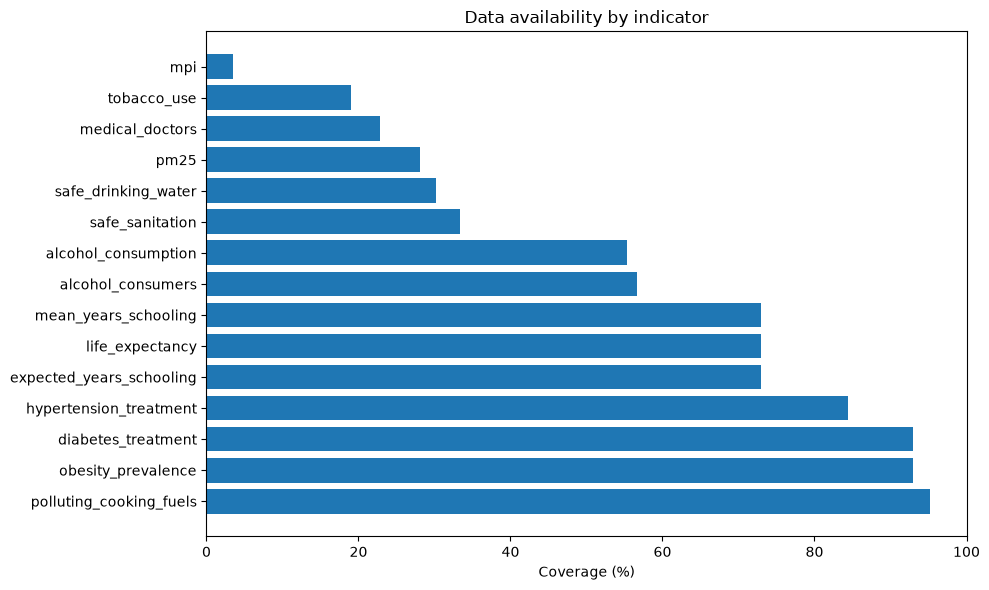

In [30]:
# Plot indicator coverage

from src.visualization import plot_indicator_coverage


coverage_plot = coverage.drop(
    index=[
        "iso3",
        "setting",
        "date"
    ],
    errors="ignore"
)


plot_indicator_coverage(
    coverage_plot,
    filename="02_indicator_coverage.png"
)

### Interpretation

The completeness analysis demonstrates substantial variation in data availability among the selected indicators.

Educational variables, obesity prevalence, diabetes treatment, hypertension treatment, and the prevalence of polluting cooking fuels exhibit high coverage across the analytical dataset, indicating their suitability for subsequent analyses.

Conversely, indicators such as the Multidimensional Poverty Index (MPI), tobacco use, PM2.5 concentrations, and medical doctors are available for a considerably smaller proportion of country-year observations. These differences primarily reflect heterogeneous reporting practices across countries and years rather than data processing errors.

The observed variation in coverage will be considered during the preprocessing stage when selecting predictors for the final machine learning models.

## Temporal data availability

The overall missingness percentage does not indicate whether data availability is stable across time.

Therefore, temporal coverage was evaluated by calculating the percentage of available observations for each indicator in each year.

This analysis helps identify whether missing values result from:

- indicators introduced only in recent years;
- historical differences in international reporting;
- limited availability of specific measurements.

In [33]:
# Calculate indicator coverage over time

coverage_by_year = (
    df
    .groupby("date")
    .apply(
        lambda x: x.notna().mean() * 100
    )
    .round(1)
)


coverage_by_year.head()

,iso3,setting,expected_years_schooling,life_expectancy,mean_years_schooling,mpi,pm25,polluting_cooking_fuels,safe_drinking_water,safe_sanitation,alcohol_consumers,alcohol_consumption,tobacco_use,obesity_prevalence,diabetes_treatment,hypertension_treatment,medical_doctors
date,,,,,,,,,,,,,,,,,
1980,100.00,100.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,100.00
1981,100.00,100.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,100.00
1982,100.00,100.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,100.00
1983,100.00,100.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,100.00
1984,100.00,100.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,100.00


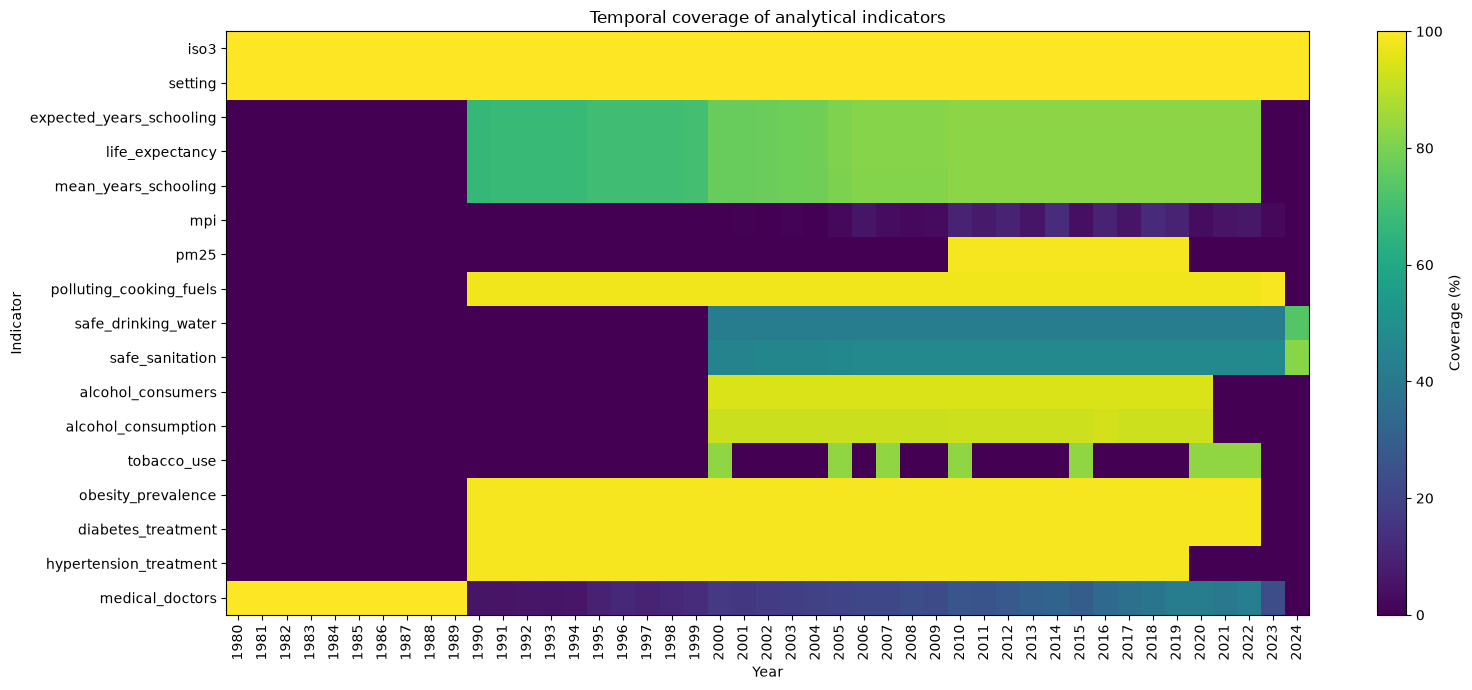

In [34]:
# Plot temporal availability of indicators

from src.visualization import plot_temporal_coverage


plot_temporal_coverage(
    coverage_by_year,
    filename="03_temporal_coverage.png"
)

## Interpretation of temporal data availability

The temporal coverage analysis revealed that the apparent high proportion of missing values observed for several indicators is primarily explained by differences in the historical availability of data rather than by random missingness.

Core development indicators, including life expectancy, expected years of schooling, and mean years of schooling, showed consistently high coverage from 1990 onwards, although no observations were available before 1990 or for the most recent years (2023–2024). This pattern likely reflects the reporting period of the original WHO and international data sources rather than data quality issues.

Several environmental and socioeconomic indicators exhibited markedly different temporal patterns. PM2.5 concentrations became available only from approximately 2010 onwards, while the Multidimensional Poverty Index (MPI) was reported for only a limited number of years, consistent with its more recent development and implementation. Similarly, indicators related to safely managed drinking water and sanitation became available mainly after 2000.

Health-related indicators also showed heterogeneous coverage. Obesity prevalence, diabetes treatment coverage, and hypertension treatment coverage were consistently available for most of the study period, making them strong candidates for predictive modelling. In contrast, tobacco use prevalence and the percentage of medical doctors exhibited substantially lower and more irregular temporal coverage.

Overall, these findings indicate that the observed missing values are largely **structural**, reflecting differences in the years during which individual indicators were collected and reported. Consequently, the missingness cannot be considered random and should be explicitly accounted for during feature selection, data preprocessing, and model development. The temporal availability of each predictor will therefore be considered when defining the final modelling dataset.

## Country-level completeness

Because the analytical unit is a country-year observation, it is also important to evaluate whether some countries contribute substantially fewer observations than others.

Countries with limited data availability may influence model training and generalization performance.

In [37]:
# Calculate data completeness by country

country_completeness = (
    df
    .groupby(
        [
            "iso3",
            "setting"
        ]
    )
    .apply(
        lambda x: x.notna().mean() * 100
    )
    .reset_index()
)


country_completeness.head()

,iso3,setting,date,expected_years_schooling,life_expectancy,mean_years_schooling,mpi,pm25,polluting_cooking_fuels,safe_drinking_water,safe_sanitation,alcohol_consumers,alcohol_consumption,tobacco_use,obesity_prevalence,diabetes_treatment,hypertension_treatment,medical_doctors
0,AFG,Afghanistan,100.00,94.29,94.29,94.29,5.71,28.57,97.14,71.43,71.43,60.00,60.00,22.86,94.29,94.29,85.71,5.71
1,AGO,Angola,100.00,70.59,70.59,70.59,0.00,29.41,100.00,0.00,0.00,61.76,61.76,0.00,97.06,97.06,88.24,0.00
2,ALB,Albania,100.00,97.06,97.06,97.06,5.88,29.41,100.00,0.00,0.00,61.76,61.76,23.53,97.06,97.06,88.24,5.88
3,AND,Andorra,100.00,0.00,0.00,0.00,0.00,28.57,97.14,0.00,71.43,60.00,60.00,22.86,94.29,94.29,85.71,40.00
4,ARE,United Arab Emirates,100.00,0.00,0.00,0.00,0.00,28.57,97.14,0.00,71.43,60.00,60.00,22.86,94.29,94.29,85.71,20.00


In [38]:
# Countries with lowest life expectancy availability

country_completeness.sort_values(
    "life_expectancy"
).head(10)

,iso3,setting,date,expected_years_schooling,life_expectancy,mean_years_schooling,mpi,pm25,polluting_cooking_fuels,safe_drinking_water,safe_sanitation,alcohol_consumers,alcohol_consumption,tobacco_use,obesity_prevalence,diabetes_treatment,hypertension_treatment,medical_doctors
108,MCO,Monaco,100.00,0.00,0.00,0.00,0.00,29.41,100.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,11.76
47,DMA,Dominica,100.00,0.00,0.00,0.00,0.00,29.41,100.00,0.00,0.00,61.76,61.76,0.00,97.06,97.06,88.24,0.00
144,PRK,Democratic People's Republic of Korea,100.00,0.00,0.00,0.00,0.00,29.41,100.00,70.59,0.00,61.76,61.76,23.53,97.06,97.06,88.24,0.00
71,GRD,Grenada,100.00,0.00,0.00,0.00,0.00,29.41,100.00,0.00,0.00,61.76,61.76,0.00,97.06,97.06,88.24,0.00
147,PSE,occupied Palestinian territory,100.00,0.00,0.00,0.00,8.57,28.57,0.00,71.43,71.43,0.00,0.00,0.00,94.29,94.29,85.71,0.00
25,BRN,Brunei Darussalam,100.00,0.00,0.00,0.00,0.00,29.41,100.00,0.00,0.00,61.76,61.76,23.53,97.06,97.06,88.24,0.00
148,QAT,Qatar,100.00,0.00,0.00,0.00,0.00,29.41,100.00,0.00,0.00,61.76,61.76,23.53,97.06,97.06,88.24,5.88
140,PLW,Palau,100.00,0.00,0.00,0.00,0.00,28.57,97.14,71.43,0.00,0.00,0.00,22.86,94.29,94.29,85.71,2.86
155,SGP,Singapore,100.00,0.00,0.00,0.00,0.00,29.41,100.00,0.00,0.00,61.76,61.76,23.53,97.06,97.06,88.24,0.00
60,FRO,Faroe Islands,100.00,0.00,0.00,0.00,0.00,0.00,100.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [39]:
# Countries with highest life expectancy availability

country_completeness.sort_values(
    "life_expectancy",
    ascending=False
).head(10)

,iso3,setting,date,expected_years_schooling,life_expectancy,mean_years_schooling,mpi,pm25,polluting_cooking_fuels,safe_drinking_water,safe_sanitation,alcohol_consumers,alcohol_consumption,tobacco_use,obesity_prevalence,diabetes_treatment,hypertension_treatment,medical_doctors
100,LBY,Libya,100.00,100.00,100.00,100.00,0.00,30.30,0.00,0.00,0.00,63.64,63.64,0.00,100.00,100.00,90.91,0.00
151,RWA,Rwanda,100.00,97.06,97.06,97.06,8.82,29.41,100.00,0.00,0.00,61.76,61.76,23.53,97.06,97.06,88.24,5.88
125,NAM,Namibia,100.00,97.06,97.06,97.06,5.88,29.41,100.00,0.00,0.00,61.76,61.76,23.53,97.06,97.06,88.24,0.00
34,CMR,Cameroon,100.00,97.06,97.06,97.06,8.82,29.41,100.00,0.00,0.00,61.76,61.76,23.53,97.06,97.06,88.24,8.82
36,COG,Congo,100.00,97.06,97.06,97.06,5.88,29.41,100.00,64.71,0.00,61.76,61.76,23.53,97.06,97.06,88.24,2.94
153,SDN,Sudan,100.00,97.06,97.06,97.06,5.88,29.41,100.00,0.00,0.00,61.76,32.35,0.00,97.06,97.06,88.24,0.00
152,SAU,Saudi Arabia,100.00,97.06,97.06,97.06,0.00,29.41,100.00,0.00,0.00,61.76,0.00,23.53,97.06,97.06,88.24,11.76
150,RUS,Russian Federation,100.00,97.06,97.06,97.06,0.00,29.41,100.00,0.00,0.00,61.76,61.76,23.53,97.06,97.06,88.24,26.47
142,POL,Poland,100.00,97.06,97.06,97.06,0.00,29.41,100.00,0.00,0.00,61.76,61.76,23.53,97.06,97.06,88.24,76.47
137,PAN,Panama,100.00,97.06,97.06,97.06,0.00,29.41,100.00,0.00,0.00,61.76,61.76,23.53,97.06,97.06,88.24,23.53


### Interpretation

Country-level completeness demonstrates that data availability differs across countries.

Countries with longer monitoring histories generally contribute more complete observations, whereas countries with limited historical reporting present more missing information.

This heterogeneity reflects differences in national surveillance systems and international reporting capacity.

No countries are removed at this stage because the objective is to preserve global representation. Instead, completeness will be considered during preprocessing and model validation.

## Distribution of the target variable

Understanding the distribution of the prediction target is essential before model development.

The analysis evaluates:

- central tendency;
- dispersion;
- skewness;
- presence of extreme observations.

Life expectancy is expected to show a relatively constrained distribution compared with economic variables, but important differences between countries may still be observed.

In [40]:
# Analyze life expectancy distribution

print(
    f"Mean: {df['life_expectancy'].mean():.2f}"
)

print(
    f"Median: {df['life_expectancy'].median():.2f}"
)

print(
    f"Skewness: {df['life_expectancy'].skew():.2f}"
)

Mean: 68.24
Median: 69.90
Skewness: -0.65


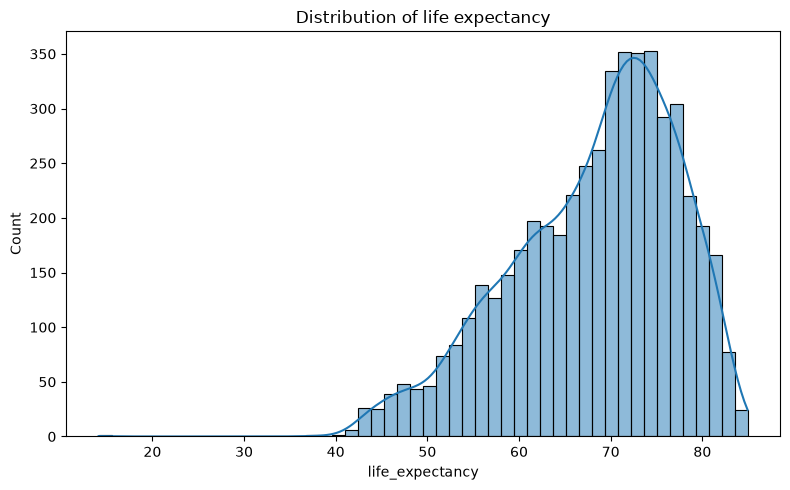

In [41]:
# Plot target distribution

from src.visualization import plot_histogram


plot_histogram(
    df["life_expectancy"],
    "Distribution of life expectancy",
    "04_life_expectancy_distribution.png"
)

### Interpretation

The target variable shows an average life expectancy of approximately **68 years**, with a median value close to **70 years**.

The negative skewness value (-0.65) indicates a moderate left-skewed distribution, meaning that a smaller number of countries with substantially lower life expectancy values pull the distribution towards the lower end.

This pattern is expected in a global health dataset, as countries affected by severe socioeconomic challenges, limited healthcare access, conflict, or high disease burden tend to present lower life expectancy values.

The distribution does not indicate extreme right-side outliers as commonly observed in economic variables such as income or property prices. Therefore, transformation of the target variable is not required at this stage.

However, the presence of lower life expectancy observations should be considered during model evaluation because errors in these countries may have greater public health relevance.

## Distribution of Predictor Variables

After evaluating the target variable, the distributions of the explanatory variables were examined.

This analysis aims to identify:

- differences in variable scales;
- skewed distributions;
- potential extreme values;
- variables requiring transformation or scaling before modelling.

Since the predictors represent different dimensions of population health (socioeconomic, environmental, behavioural and healthcare factors), heterogeneous distributions are expected.

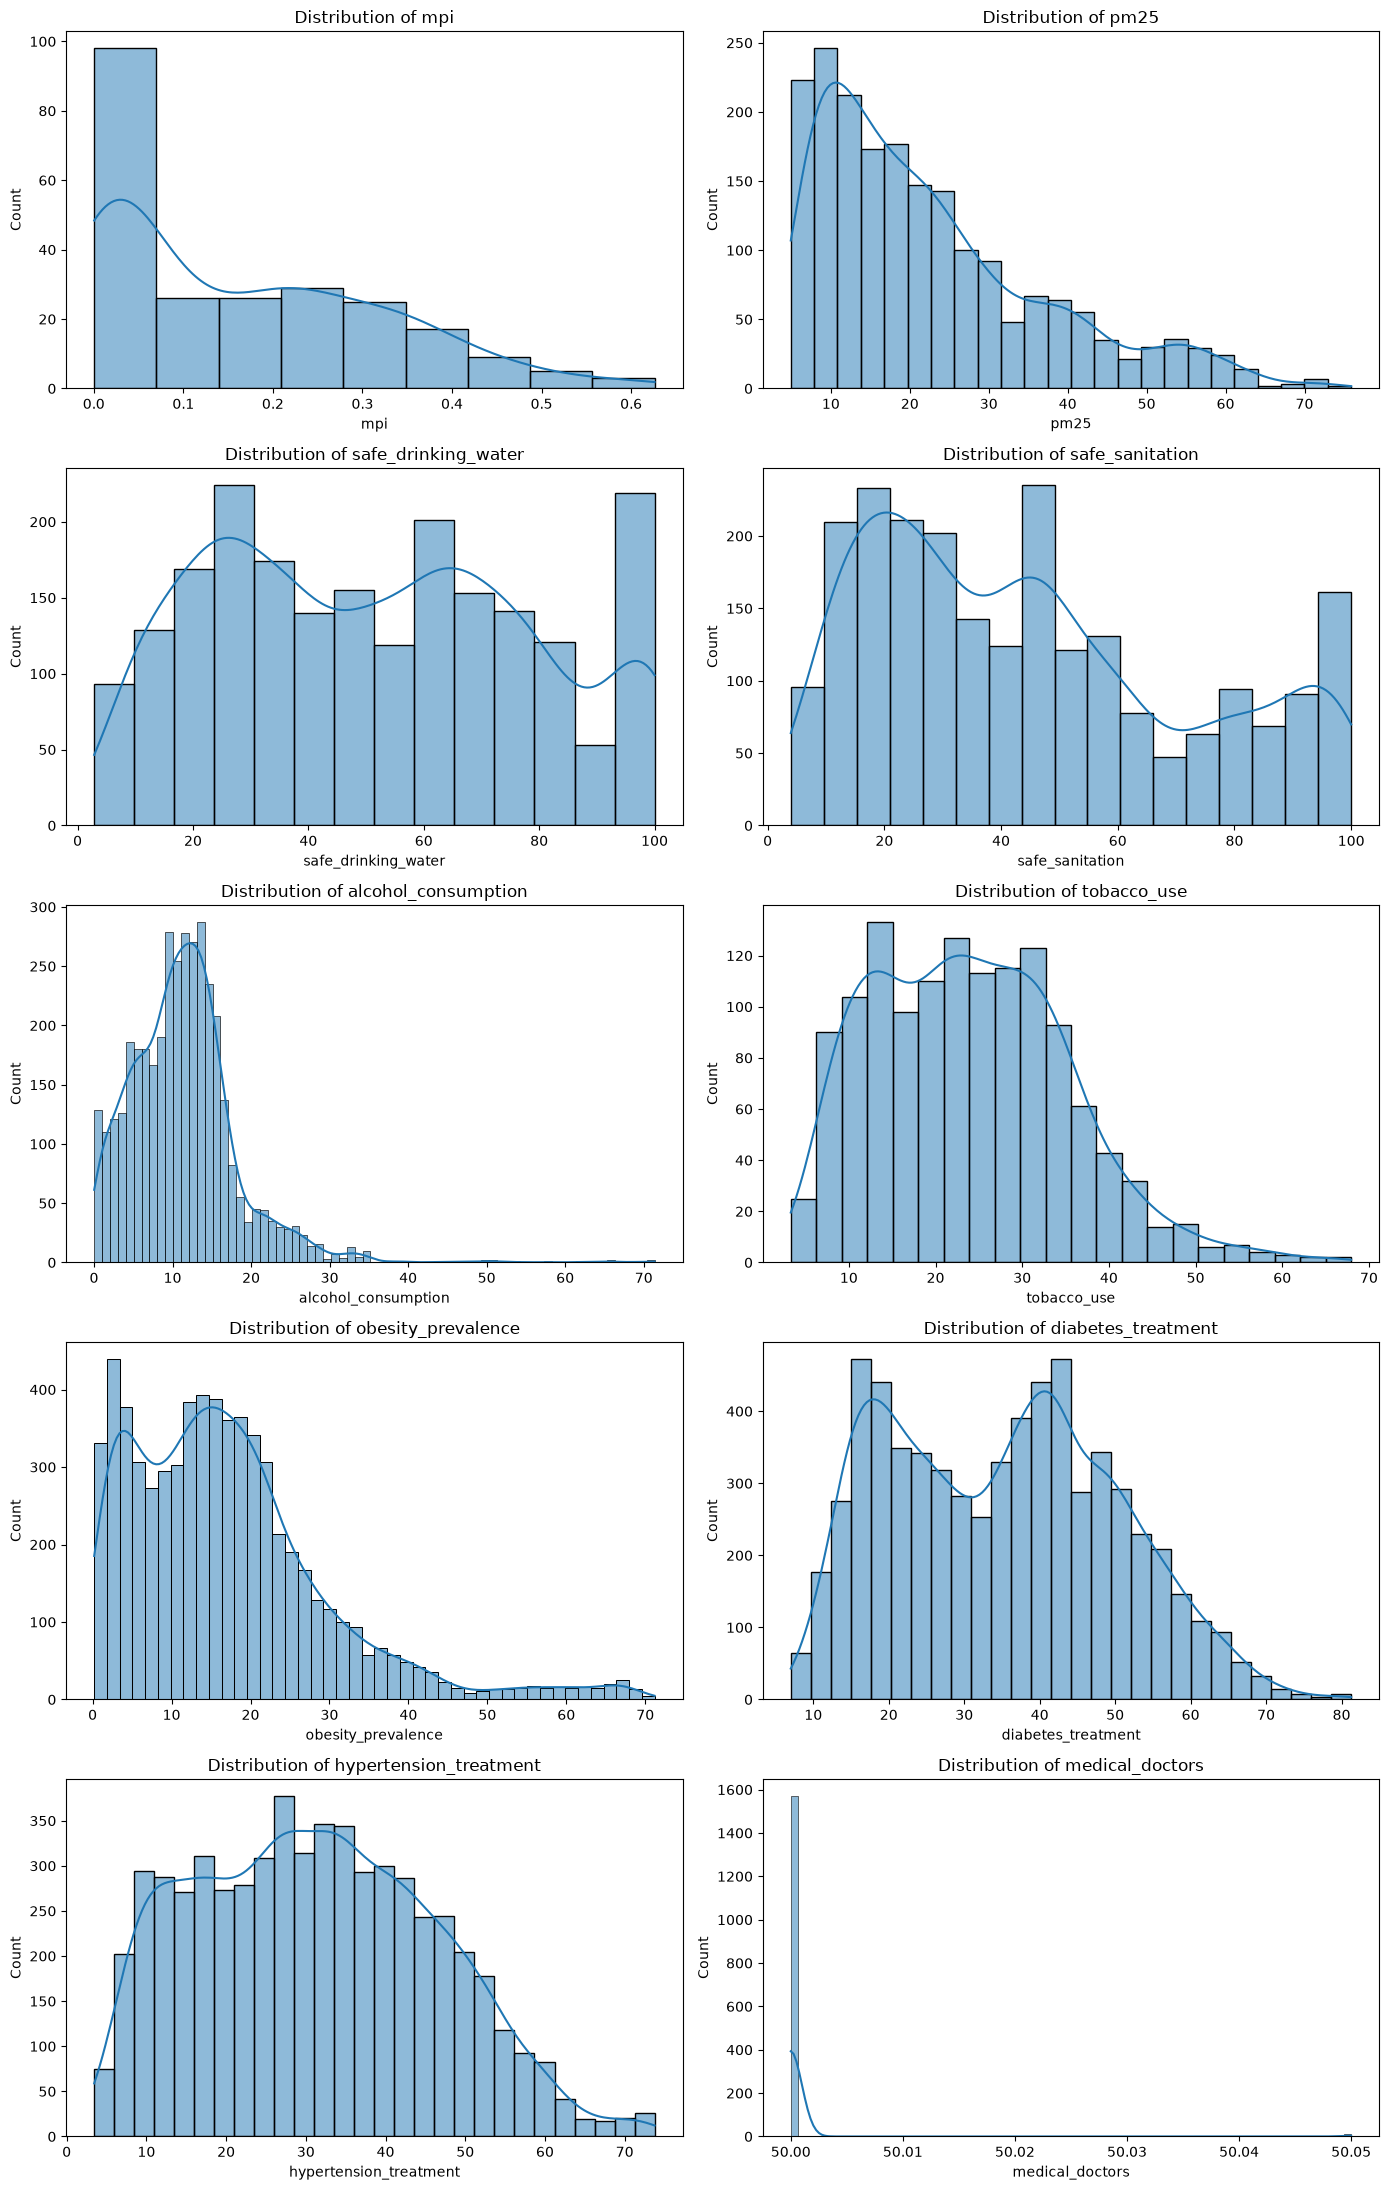

In [43]:
# Distribution of predictor variables

import matplotlib.pyplot as plt
import seaborn as sns


# Select only modelling predictors
predictors = [
    "mpi",
    "pm25",
    "safe_drinking_water",
    "safe_sanitation",
    "alcohol_consumption",
    "tobacco_use",
    "obesity_prevalence",
    "diabetes_treatment",
    "hypertension_treatment",
    "medical_doctors",
]


# Plot distributions

fig, axes = plt.subplots(
    nrows=5,
    ncols=2,
    figsize=(14, 22)
)

axes = axes.flatten()


for ax, col in zip(axes, predictors):

    sns.histplot(
        df[col],
        kde=True,
        ax=ax
    )

    ax.set_title(
        f"Distribution of {col}"
    )

    ax.set_xlabel(col)


plt.tight_layout()

plt.show()

### Interpretation

The predictor variables show heterogeneous distributions, reflecting the different characteristics of the health indicators included in the analytical dataset.

Socioeconomic indicators such as the Multidimensional Poverty Index (MPI) present a right-skewed distribution, as expected, because severe deprivation is concentrated in a smaller number of countries.

Environmental indicators such as PM2.5 concentrations also show substantial variability, reflecting differences in environmental exposure between countries.

Healthcare-related indicators, including medical doctors availability and treatment coverage variables, present wider ranges associated with differences in healthcare infrastructure and access.

Behavioural risk factors, such as tobacco use, alcohol consumption and obesity prevalence, show more symmetrical distributions, although country-level differences remain substantial.

Because the predictors are measured in different units and scales, standardization will be required before training regression models, particularly for algorithms sensitive to feature magnitude such as Linear Regression with regularization methods.